Celda 1: Importación de Librerías y Configuración de Semillas

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix

# TensorFlow y Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Intentar importar TabPFN y verificar disponibilidad de librerías
TABPFN_AVAILABLE = False
try:
    from tabpfn import TabPFNClassifier
    TABPFN_AVAILABLE = True
    print("✅ Módulo 'tabpfn' detectado e importado correctamente.")
except ImportError:
    print("❌ No se pudo importar 'tabpfn'. Asegúrate de que esté instalado en tu entorno virtual.")

# Configurar semillas para reproducibilidad estricta
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Ruta absoluta al checkpoint de clasificación binaria proporcionada
CKPT_CLASSIFIER_PATH = r"C:\Users\fundacion\PycharmProjects\cifo_machine_learning_2026\tabpfn_driver\tabpfn-v3-classifier-v3_20260417_binary.ckpt"

print(f"Ruta configurada para TabPFN v3: {CKPT_CLASSIFIER_PATH}")

✅ Módulo 'tabpfn' detectado e importado correctamente.
Ruta configurada para TabPFN v3: C:\Users\fundacion\PycharmProjects\cifo_machine_learning_2026\tabpfn_driver\tabpfn-v3-classifier-v3_20260417_binary.ckpt


Celda 2: Carga de Datos y Feature Engineering

In [2]:
# Rutas locales relativas de los conjuntos de datos
TRAIN_PATH = "data/train.csv"
TEST_PATH = "data/test.csv"

# Cargar conjuntos de datos
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

def preprocess_features(df):
    df_copy = df.copy()
    
    # 1. Agrupación y tamaño del grupo de PassengerId
    df_copy[['PassengerGroup', 'PassengerNum']] = df_copy['PassengerId'].str.split('_', expand=True)
    df_copy['PassengerGroup'] = df_copy['PassengerGroup'].astype(int)
    group_sizes = df_copy['PassengerGroup'].value_counts()
    df_copy['GroupSize'] = df_copy['PassengerGroup'].map(group_sizes)
    
    # 2. Cabin Splitting (Deck / Num / Side)
    df_copy['Cabin'].fillna('Missing/Missing/Missing', inplace=True)
    cabin_split = df_copy['Cabin'].str.split('/', expand=True)
    df_copy['Cabin_Deck'] = cabin_split[0]
    df_copy['Cabin_Side'] = cabin_split[2]
    
    # 3. Sumarización de Gastos de Lujo
    luxury_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    for col in luxury_cols:
        df_copy[col] = df_copy[col].fillna(0)
    df_copy['TotalSpend'] = df_copy[luxury_cols].sum(axis=1)
    df_copy['HasSpent'] = (df_copy['TotalSpend'] > 0).astype(int)
    
    # Eliminar identificadores innecesarios de alta cardinalidad
    cols_to_drop = ['PassengerId', 'Cabin', 'Name', 'PassengerNum']
    df_copy.drop(columns=[c for c in cols_to_drop if c in df_copy.columns], inplace=True)
    
    return df_copy

# Procesar los conjuntos de datos
train_processed = preprocess_features(train_df)
test_processed = preprocess_features(test_df)

X = train_processed.drop(columns=['Transported'])
y = train_processed['Transported'].astype(int)
X_test = test_processed.copy()

print("✅ Preprocesamiento e Ingeniería de características completados.")
print(f"Características de Entrenamiento: {X.shape} | Objetivo: {y.shape}")

✅ Preprocesamiento e Ingeniería de características completados.
Características de Entrenamiento: (8693, 16) | Objetivo: (8693,)


C:\Users\fundacion\AppData\Local\Temp\ipykernel_5584\2553982554.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['Cabin'].fillna('Missing/Missing/Missing', inplace=True)
C:\Users\fundacion\AppData\Local\Temp\ipykernel_5584\2553982554.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

Celda 3: Definición del Pipeline de Preprocesamiento de Datos

In [3]:
# Definición de variables numéricas y categóricas
numeric_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend', 'GroupSize']
categorical_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin_Deck', 'Cabin_Side', 'HasSpent']

# Configuración del transformador de columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols)
    ]
)

print("✅ Pipeline preprocesador configurado de forma independiente.")

✅ Pipeline preprocesador configurado de forma independiente.


Celda 4: Constructores de Modelos (ResNet Tabular & TabPFN v3)

In [4]:
# Constructor de la arquitectura Red Neuronal (ResNet)
def build_resnet_model(input_dim):
    inputs = layers.Input(shape=(input_dim,))
    
    # Capa de entrada
    x = layers.Dense(128, activation='swish')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    # Primer bloque residual
    residual_1 = x
    x = layers.Dense(128, activation='swish')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='swish')(x)
    x = layers.BatchNormalization()(x)
    x = layers.add([x, residual_1])
    
    # Segundo bloque residual
    residual_2 = x
    x = layers.Dense(128, activation='swish')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='swish')(x)
    x = layers.BatchNormalization()(x)
    x = layers.add([x, residual_2])
    
    # Capa de salida e intermedia
    x = layers.Dense(64, activation='swish')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Función generadora para TabPFN v3 usando su checkpoint local
def build_tabpfn_v3():
    if not TABPFN_AVAILABLE:
        raise RuntimeError("El framework TabPFN v3 no está instalado o accesible en este entorno virtual.")
        
    if not os.path.exists(CKPT_CLASSIFIER_PATH):
        raise FileNotFoundError(f"Error: No se encuentra el archivo en la ruta especificada:\n{CKPT_CLASSIFIER_PATH}")
        
    # Inicialización del driver de clasificación TabPFN v3 con el archivo .ckpt local
    tabpfn_classifier = TabPFNClassifier(
        model_path=CKPT_CLASSIFIER_PATH,
        device='cpu',
        ignore_pretraining_limits=True
    )
    return tabpfn_classifier

print("✅ Generadores de modelos listos para la validación cruzada.")

✅ Generadores de modelos listos para la validación cruzada.


Celda 5: Loop de Validación Cruzada (Stratified K-Fold)

In [5]:
# Configurar la validación cruzada de 5 pliegues
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

resnet_scores = []
tabpfn_scores = []

# Listas auxiliares para las predicciones fuera de muestra (oof) globales
y_true_all = []
resnet_preds_all = []
tabpfn_preds_all = []

print(f"🔄 Iniciando Validación Cruzada de {N_SPLITS} pliegues con Balanced Accuracy...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n--- 📦 Procesando Fold {fold + 1}/{N_SPLITS} ---")
    
    # Segmentación de datos del fold
    X_train_f, X_val_f = X.iloc[train_idx], X.iloc[val_idx]
    y_train_f, y_val_f = y.iloc[train_idx], y.iloc[val_idx]
    
    # Ajustar preprocesador SOLO con train del fold actual para evitar Data Leakage
    X_train_f_pre = preprocessor.fit_transform(X_train_f)
    X_val_f_pre = preprocessor.transform(X_val_f)
    
    # ------------------ 1. EVALUACIÓN DE RESNET ------------------
    resnet_clf = build_resnet_model(X_train_f_pre.shape[1])
    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=0)
    ]
    
    resnet_clf.fit(
        X_train_f_pre, y_train_f,
        validation_data=(X_val_f_pre, y_val_f),
        epochs=80,
        batch_size=64,
        callbacks=callbacks,
        verbose=0
    )
    
    # Predecir con ResNet y calcular Balanced Accuracy
    resnet_preds_prob = resnet_clf.predict(X_val_f_pre, verbose=0)
    resnet_preds = (resnet_preds_prob > 0.5).astype(int).flatten()
    resnet_acc = balanced_accuracy_score(y_val_f, resnet_preds)
    resnet_scores.append(resnet_acc)
    
    # ------------------ 2. EVALUACIÓN DE TABPFN V3 ------------------
    try:
        tabpfn_clf = build_tabpfn_v3()
        # Ajuste e Inferencia In-Context del Clasificador de TabPFN
        tabpfn_clf.fit(X_train_f_pre, y_train_f)
        tabpfn_preds = tabpfn_clf.predict(X_val_f_pre)
        tabpfn_acc = balanced_accuracy_score(y_val_f, tabpfn_preds)
        tabpfn_scores.append(tabpfn_acc)
    except Exception as e:
        print(f"❌ Error en TabPFN v3 (Fold {fold + 1}): {e}")
        tabpfn_scores.append(np.nan)
        tabpfn_preds = np.zeros_like(y_val_f)
    
    # Acumulación para estadísticas globales
    y_true_all.extend(y_val_f.tolist())
    resnet_preds_all.extend(resnet_preds.tolist())
    tabpfn_preds_all.extend(tabpfn_preds.tolist())
    
    print(f"Fold {fold + 1} Completado | Balanced Acc -> ResNet: {resnet_acc:.4f} | TabPFN v3: {tabpfn_acc:.4f}")

print("\n✅ Validación cruzada finalizada.")

🔄 Iniciando Validación Cruzada de 5 pliegues con Balanced Accuracy...

--- 📦 Procesando Fold 1/5 ---
Fold 1 Completado | Balanced Acc -> ResNet: 0.8109 | TabPFN v3: 0.8158

--- 📦 Procesando Fold 2/5 ---
Fold 2 Completado | Balanced Acc -> ResNet: 0.7943 | TabPFN v3: 0.7992

--- 📦 Procesando Fold 3/5 ---
Fold 3 Completado | Balanced Acc -> ResNet: 0.8074 | TabPFN v3: 0.8100

--- 📦 Procesando Fold 4/5 ---
Fold 4 Completado | Balanced Acc -> ResNet: 0.8209 | TabPFN v3: 0.8243

--- 📦 Procesando Fold 5/5 ---
Fold 5 Completado | Balanced Acc -> ResNet: 0.7894 | TabPFN v3: 0.7933

✅ Validación cruzada finalizada.


Celda 6: Comparación de Rendimiento de los Modelos

📊 RESUMEN DE COMPARACIÓN (Balanced Accuracy):
ResNet Tabular ➡️ Media: 0.8046 | Desviación Estándar (std): 0.0114
TabPFN v3      ➡️ Media: 0.8085 | Desviación Estándar (std): 0.0112


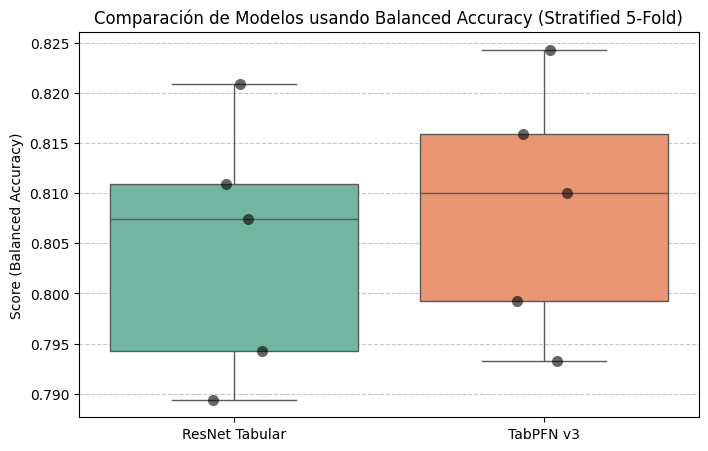

In [6]:
# Crear dataframe con los resultados de la validación cruzada
cv_results = pd.DataFrame({
    'Fold': range(1, N_SPLITS + 1),
    'ResNet Tabular': resnet_scores,
    'TabPFN v3': tabpfn_scores
})

print("📊 RESUMEN DE COMPARACIÓN (Balanced Accuracy):")
print("=" * 60)
print(f"ResNet Tabular ➡️ Media: {np.nanmean(resnet_scores):.4f} | Desviación Estándar (std): {np.nanstd(resnet_scores):.4f}")
print(f"TabPFN v3      ➡️ Media: {np.nanmean(tabpfn_scores):.4f} | Desviación Estándar (std): {np.nanstd(tabpfn_scores):.4f}")
print("=" * 60)

# Gráfico de cajas (Boxplot) comparativo
plt.figure(figsize=(8, 5))
sns.boxplot(data=cv_results[['ResNet Tabular', 'TabPFN v3']], palette="Set2")
sns.stripplot(data=cv_results[['ResNet Tabular', 'TabPFN v3']], color="black", alpha=0.6, size=8)
plt.title('Comparación de Modelos usando Balanced Accuracy (Stratified 5-Fold)', fontsize=12)
plt.ylabel('Score (Balanced Accuracy)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('cv_comparison_resnet_vs_tabpfn.png', dpi=300)
plt.show()

Celda 7: Matrices de Confusión y Reporte Global Out-of-Fold

=== REPORTE DE CLASIFICACIÓN DETALLADO: RESNET ===
                 precision    recall  f1-score   support

No Transportado       0.80      0.81      0.80      4315
    Transported       0.81      0.80      0.80      4378

       accuracy                           0.80      8693
      macro avg       0.80      0.80      0.80      8693
   weighted avg       0.80      0.80      0.80      8693


=== REPORTE DE CLASIFICACIÓN DETALLADO: TABPFN v3 ===
                 precision    recall  f1-score   support

No Transportado       0.82      0.79      0.80      4315
    Transported       0.80      0.83      0.81      4378

       accuracy                           0.81      8693
      macro avg       0.81      0.81      0.81      8693
   weighted avg       0.81      0.81      0.81      8693



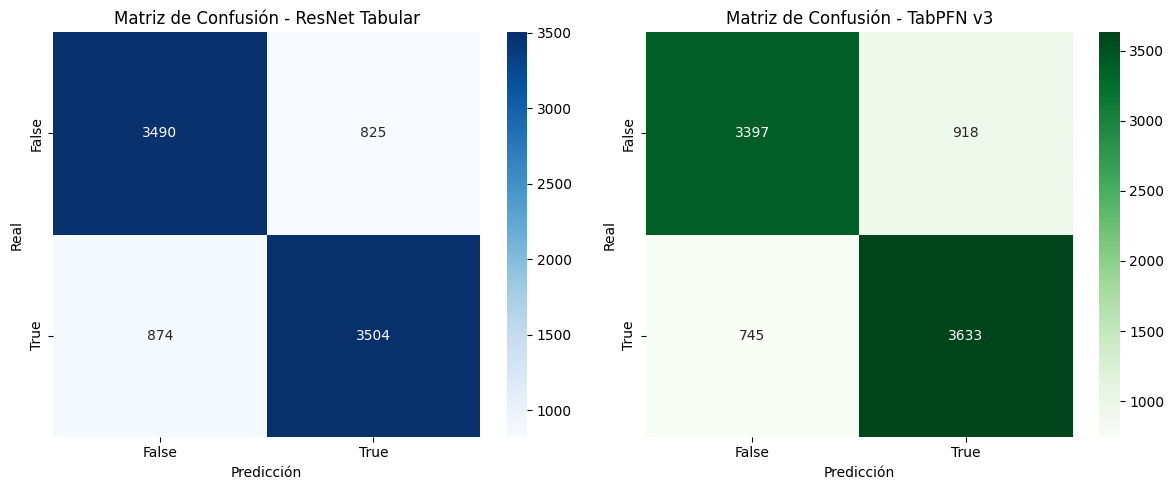

In [7]:
print("=== REPORTE DE CLASIFICACIÓN DETALLADO: RESNET ===")
print(classification_report(y_true_all, resnet_preds_all, target_names=['No Transportado', 'Transported']))

print("\n=== REPORTE DE CLASIFICACIÓN DETALLADO: TABPFN v3 ===")
print(classification_report(y_true_all, tabpfn_preds_all, target_names=['No Transportado', 'Transported']))

# Visualizar matrices de confusión lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de Confusión ResNet
cm_resnet = confusion_matrix(y_true_all, resnet_preds_all)
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['False', 'True'], yticklabels=['False', 'True'])
axes[0].set_title('Matriz de Confusión - ResNet Tabular')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicción')

# Matriz de Confusión TabPFN v3
cm_tabpfn = confusion_matrix(y_true_all, tabpfn_preds_all)
sns.heatmap(cm_tabpfn, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['False', 'True'], yticklabels=['False', 'True'])
axes[1].set_title('Matriz de Confusión - TabPFN v3')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicción')

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=300)
plt.show()

Celda 8: Entrenamiento Final del Modelo Ganador y Generación de Submission

In [8]:
# Decidir modelo ganador basándonos en la media obtenida
mean_resnet = np.nanmean(resnet_scores)
mean_tabpfn = np.nanmean(tabpfn_scores)

best_model_name = "TabPFN v3" if mean_tabpfn > mean_resnet else "ResNet Tabular"
print(f"🏆 El modelo ganador es: {best_model_name} ({max(mean_resnet, mean_tabpfn):.4f} Balanced Accuracy)")

# Preprocesar todo el dataset de entrenamiento
X_all_pre = preprocessor.fit_transform(X)
X_test_all_pre = preprocessor.transform(X_test)

if best_model_name == "TabPFN v3":
    print("Ajustando modelo final TabPFN v3 sobre todo el dataset...")
    final_model = build_tabpfn_v3()
    final_model.fit(X_all_pre, y)
    predictions = final_model.predict(X_test_all_pre).astype(bool)
else:
    print("Entrenando modelo final ResNet Tabular sobre todo el dataset...")
    final_model = build_resnet_model(X_all_pre.shape[1])
    early_stop = keras.callbacks.EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
    final_model.fit(X_all_pre, y, epochs=80, batch_size=64, callbacks=[early_stop], verbose=1)
    preds_prob = final_model.predict(X_test_all_pre)
    predictions = (preds_prob > 0.5).flatten()

# Generación del DataFrame final
submission_df = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Transported': predictions
})

# Exportar CSV de sumisión oficial
submission_df.to_csv('submission_final_project_cv.csv', index=False)
print("\n✅ ¡Fichero 'submission_final_project_cv.csv' guardado con éxito!")
print(submission_df['Transported'].value_counts())

🏆 El modelo ganador es: TabPFN v3 (0.8085 Balanced Accuracy)
Ajustando modelo final TabPFN v3 sobre todo el dataset...

✅ ¡Fichero 'submission_final_project_cv.csv' guardado con éxito!
Transported
True     2275
False    2002
Name: count, dtype: int64
